## Install library- One time installation

In [1]:
!pip install lightgbm 

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 356.7 kB/s eta 0:00:03
   -------------- ------------------------- 0.5/1.5 MB 356.7 kB/s eta 0:00:03
   -------------- ------------------------- 0.5/1.5 MB 356.7 kB/s eta 0:00:03
   --------------------- ------------------ 0.8/1.5 MB 372.6 kB/s eta 0:00:02
   --------------------- ------------------ 0.8/1.5 MB 372.6 kB/s eta 0:00:02
   --------------------- ------------------ 0.8/1.5 MB 372.6 kB/s eta 0:00:02
   --------------------- ------------------ 0.8/1

## Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

ModuleNotFoundError: No module named 'lightgbm'

## Load the Data

In [ ]:
mnist = fetch_openml('mnist_784', version=1)
X = pd.DataFrame(mnist.data)
y = mnist.target.astype(int)

In [3]:
## Data overview
print("Shape of features:", X.shape)  ## (70000, 784)
print("Shape of target:", y.shape)     ## (70000,)

NameError: name 'X' is not defined

## Data Visualization: Displaying Random Images

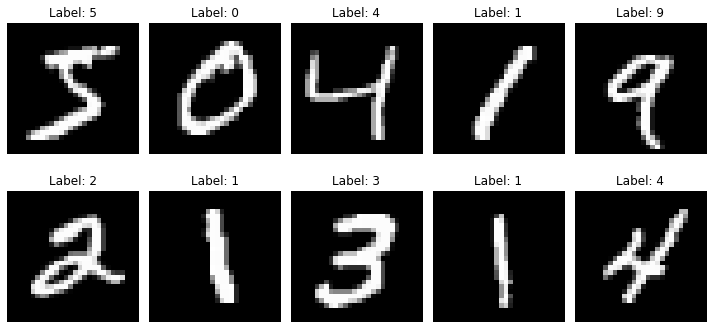

In [5]:
def plot_random_images(images, labels, n=10):
    plt.figure(figsize=(10, 5))
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Display random images
plot_random_images(X.to_numpy(), y.to_numpy())

## Split the Data

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create LightGBM Dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

## Train the LightGBM Model

In [7]:
# Set parameters for LightGBM
params = {
    'objective': 'multiclass',
    'num_class': 10,
    'metric': 'multi_logloss',
    'learning_rate': 0.1,
    'num_leaves': 31,
    'max_depth': -1,
    'n_estimators': 100,
}

# Train the LightGBM model
model = lgb.train(params, train_data, num_boost_round=100)

C:\Users\sriam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.298972 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 108666
[LightGBM] [Info] Number of data points in the train set: 56000, number of used features: 626
[LightGBM] [Info] Start training from score -2.309754
[LightGBM] [Info] Start training from score -2.188460
[LightGBM] [Info] Start training from score -2.300801
[LightGBM] [Info] Start training from score -2.283483
[LightGBM] [Info] Start training from score -2.315345
[LightGBM] [Info] Start training from score -2.407946
[LightGBM] [Info] Start training from score -2.324247
[LightGBM] [Info] Start training from score -2.269219
[LightGBM] [Info] Start training from score -2.326439
[LightGBM] [Info] Start training from score -2.313718


## Make Predictions & evaluate the Model

In [11]:
y_train_pred = model.predict(X_train, num_iteration=model.best_iteration)
y_train_pred = np.argmax(y_train_pred, axis=1)

y_test_pred = model.predict(X_test, num_iteration=model.best_iteration)
y_test_pred = np.argmax(y_test_pred, axis=1)

print("Train Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))
print("\nTrain Classification Report:")
print(classification_report(y_train, y_train_pred))

print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

Train Confusion Matrix:
[[5560    0    0    0    0    0    0    0    0    0]
 [   0 6277    0    0    0    0    0    0    0    0]
 [   0    0 5610    0    0    0    0    0    0    0]
 [   0    0    0 5708    0    0    0    0    0    0]
 [   0    0    0    0 5529    0    0    0    0    0]
 [   0    0    0    0    0 5040    0    0    0    0]
 [   0    0    0    0    0    0 5480    0    0    0]
 [   0    0    0    0    0    0    0 5790    0    0]
 [   0    0    0    0    0    0    0    0 5468    0]
 [   0    0    0    0    0    0    0    0    0 5538]]

Train Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5560
           1       1.00      1.00      1.00      6277
           2       1.00      1.00      1.00      5610
           3       1.00      1.00      1.00      5708
           4       1.00      1.00      1.00      5529
           5       1.00      1.00      1.00      5040
           6       1.00      1.00   